
# Edge AI Assignment: Neural Network from Scratch (Checkerboard Classification)

## Objective
Build a simple neural network **from scratch (no ML libraries)** to classify a 2D checkerboard pattern.

You will:
- Implement forward propagation
- Implement backpropagation
- Train a small neural network
- Visualize the decision boundary

---

## Dataset Concept
We generate (x, y) points and assign labels based on a checkerboard pattern.

This is a **non-linear classification problem** (like XOR, but extended to 2D).


In [ ]:

import numpy as np
import matplotlib.pyplot as plt


## Step 1: Generate Checkerboard Data

In [ ]:

def generate_data(n_samples=3000, k=4):
    X = np.random.uniform(-1, 1, (n_samples, 2))

    # Checkerboard labels
    y = ((np.floor((X[:,0]+1)*k) + np.floor((X[:,1]+1)*k)) % 2)

    return X, y.reshape(-1, 1)

X, y = generate_data()


## Visualize Dataset

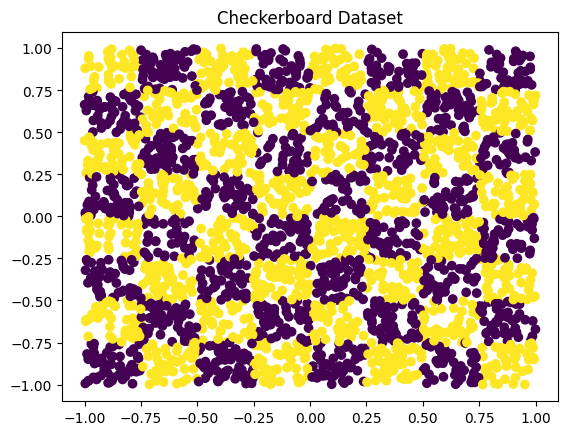

In [ ]:

plt.scatter(X[:,0], X[:,1], c=y.flatten())
plt.title("Checkerboard Dataset")
plt.show()



## Step 2: Build Neural Network

Architecture:
- Input: 2 neurons (x, y)
- Hidden: YOU DECIDE
- Output: 1 neuron (sigmoid)

Fill in missing parts.


In [ ]:
import numpy as np

# Initialize weights for a three-hidden-layer network using He initialization for ReLU layers
def init_params(input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size):
    # He initialization for ReLU layers (sqrt(2 / input_dim))
    W1 = np.random.randn(input_size, hidden_size_1) * np.sqrt(2 / input_size)
    b1 = np.zeros((1, hidden_size_1))

    W2 = np.random.randn(hidden_size_1, hidden_size_2) * np.sqrt(2 / hidden_size_1)
    b2 = np.zeros((1, hidden_size_2))

    W3 = np.random.randn(hidden_size_2, hidden_size_3) * np.sqrt(2 / hidden_size_2)
    b3 = np.zeros((1, hidden_size_3))

    # Smaller weights for sigmoid output layer (e.g., Xavier/Glorot or just small random)
    W4 = np.random.randn(hidden_size_3, output_size) * 0.01 # Can also use np.sqrt(1 / hidden_size_3) for Xavier
    b4 = np.zeros((1, output_size))

    return W1, b1, W2, b2, W3, b3, W4, b4

## Activation Functions

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

In [ ]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

### Explanation of ReLU Implementation

*   **`relu(x)`**: This function computes the Rectified Linear Unit activation, returning `x` if `x > 0` and `0` otherwise. `np.maximum(0, x)` is an efficient way to achieve this.
*   **`relu_derivative(x)`**: This function computes the derivative of the ReLU function. The derivative is `1` for `x > 0` and `0` for `x <= 0`. We use `(x > 0).astype(float)` to get `1.0` where `x` is positive and `0.0` otherwise.

Now, let's update the `forward` and `backward` functions to use ReLU for the hidden layer and Sigmoid for the output layer.

In [ ]:
# Modified Forward Pass for two hidden layers with ReLU
def forward(X, W1, b1, W2, b2, W3, b3):
    # 1. First hidden layer
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    # 2. Second hidden layer
    Z2 = np.dot(A1, W2) + b2
    A2 = relu(Z2)

    # 3. Output layer
    Z3 = np.dot(A2, W3) + b3
    A3 = sigmoid(Z3) # Sigmoid for output layer

    # 4. Return output + intermediates
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "A3": A3}
    return A3, cache

In [ ]:
# Modified Backpropagation for two hidden layers with ReLU derivative
def backward(X, y, W1, b1, W2, b2, W3, b3, cache):
    m = X.shape[0]

    Z1 = cache["Z1"]
    A1 = cache["A1"]
    Z2 = cache["Z2"]
    A2 = cache["A2"]
    A3 = cache["A3"]

    # Output layer gradients (sigmoid derivative is handled by dZ3 = A3 - y)
    dZ3 = A3 - y # Derivative of loss w.r.t Z3 (for sigmoid + binary cross-entropy)
    dW3 = np.dot(A2.T, dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # Second hidden layer gradients (using ReLU derivative)
    dA2 = np.dot(dZ3, W3.T)
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # First hidden layer gradients (using ReLU derivative)
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2, dW3, db3

Now that we've updated the `forward` and `backward` functions to use ReLU for the hidden layer, you can re-run the training cell to see the effect on the loss and decision boundary.

## Forward Pass

In [ ]:
# Modified Forward Pass for three hidden layers with ReLU
def forward(X, W1, b1, W2, b2, W3, b3, W4, b4):
    # 1. First hidden layer
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    # 2. Second hidden layer
    Z2 = np.dot(A1, W2) + b2
    A2 = relu(Z2)

    # 3. Third hidden layer
    Z3 = np.dot(A2, W3) + b3
    A3 = relu(Z3)

    # 4. Output layer
    Z4 = np.dot(A3, W4) + b4
    A4 = sigmoid(Z4) # Sigmoid for output layer

    # 5. Return output + intermediates
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "A3": A3, "Z4": Z4, "A4": A4}
    return A4, cache

## Loss Function

In [ ]:
def compute_loss(y_true, y_pred):
    # Binary cross-entropy
    # Clip predictions to avoid log(0)
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1. - epsilon)
    loss = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return np.mean(loss)

## Backpropagation

In [ ]:
# Modified Backpropagation for three hidden layers with ReLU derivative
def backward(X, y, W1, b1, W2, b2, W3, b3, W4, b4, cache):
    m = X.shape[0]

    Z1 = cache["Z1"]
    A1 = cache["A1"]
    Z2 = cache["Z2"]
    A2 = cache["A2"]
    Z3 = cache["Z3"]
    A3 = cache["A3"]
    A4 = cache["A4"]

    # Output layer gradients (sigmoid derivative is handled by dZ4 = A4 - y)
    dZ4 = A4 - y # Derivative of loss w.r.t Z4 (for sigmoid + binary cross-entropy)
    dW4 = np.dot(A3.T, dZ4) / m
    db4 = np.sum(dZ4, axis=0, keepdims=True) / m

    # Third hidden layer gradients (using ReLU derivative)
    dA3 = np.dot(dZ4, W4.T)
    dZ3 = dA3 * relu_derivative(Z3)
    dW3 = np.dot(A2.T, dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # Second hidden layer gradients (using ReLU derivative)
    dA2 = np.dot(dZ3, W3.T)
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # First hidden layer gradients (using ReLU derivative)
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2, dW3, db3, dW4, db4

In [ ]:
def calculate_accuracy(y_true, y_pred):
    predictions = (y_pred > 0.5).astype(int)
    accuracy = np.mean(predictions == y_true)
    return accuracy

## Training Loop

In [ ]:
def create_mini_batches(X, y, batch_size):
    m = X.shape[0]
    mini_batches = []

    # Shuffle (X, y)
    permutation = list(np.random.permutation(m))
    shuffled_X = X[permutation, :]
    shuffled_y = y[permutation, :]

    num_complete_batches = np.floor(m / batch_size).astype(int)

    for k in range(num_complete_batches):
        mini_batch_X = shuffled_X[k * batch_size : (k + 1) * batch_size, :]
        mini_batch_y = shuffled_y[k * batch_size : (k + 1) * batch_size, :]
        mini_batches.append((mini_batch_X, mini_batch_y))

    # Handle the end case (last mini-batch < batch_size)
    if m % batch_size != 0:
        mini_batch_X = shuffled_X[num_complete_batches * batch_size : m, :]
        mini_batch_y = shuffled_y[num_complete_batches * batch_size : m, :]
        mini_batches.append((mini_batch_X, mini_batch_y))

    return mini_batches

In [ ]:
def train(X, y, hidden_size_1=16, hidden_size_2=8, hidden_size_3=4, lr=0.01, epochs=5000):
    W1, b1, W2, b2, W3, b3, W4, b4 = init_params(2, hidden_size_1, hidden_size_2, hidden_size_3, 1)
    loss_history = []

    for epoch in range(epochs):
        # Forward
        A4, cache = forward(X, W1, b1, W2, b2, W3, b3, W4, b4)

        # Loss
        loss = compute_loss(y, A4)
        loss_history.append(loss)

        # Backward
        dW1, db1, dW2, db2, dW3, db3, dW4, db4 = backward(X, y, W1, b1, W2, b2, W3, b3, W4, b4, cache)

        # Update weights
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
        W3 -= lr * dW3
        b3 -= lr * db3
        W4 -= lr * dW4
        b4 -= lr * db4

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return W1, b1, W2, b2, W3, b3, W4, b4, loss_history

In [ ]:
def train_mini_batch(X, y, hidden_size_1=32, hidden_size_2=16, hidden_size_3=8, lr=0.01, epochs=5000, batch_size=64):
    W1, b1, W2, b2, W3, b3, W4, b4 = init_params(2, hidden_size_1, hidden_size_2, hidden_size_3, 1)
    loss_history = []

    for epoch in range(epochs):
        # Create mini-batches
        mini_batches = create_mini_batches(X, y, batch_size)
        epoch_loss = 0

        for mini_batch_X, mini_batch_y in mini_batches:
            # Forward
            A4, cache = forward(mini_batch_X, W1, b1, W2, b2, W3, b3, W4, b4)

            # Loss
            loss = compute_loss(mini_batch_y, A4)
            epoch_loss += loss

            # Backward
            dW1, db1, dW2, db2, dW3, db3, dW4, db4 = backward(mini_batch_X, mini_batch_y, W1, b1, W2, b2, W3, b3, W4, b4, cache)

            # Update weights
            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2
            W3 -= lr * dW3
            b3 -= lr * db3
            W4 -= lr * dW4
            b4 -= lr * db4

        avg_epoch_loss = epoch_loss / len(mini_batches)
        loss_history.append(avg_epoch_loss)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {avg_epoch_loss:.4f}")

    return W1, b1, W2, b2, W3, b3, W4, b4, loss_history

Epoch 0, Loss: 0.6925
Epoch 100, Loss: 0.6780
Epoch 200, Loss: 0.6410
Epoch 300, Loss: 0.5819
Epoch 400, Loss: 0.5405
Epoch 500, Loss: 0.5020
Epoch 600, Loss: 0.4931
Epoch 700, Loss: 0.4520
Epoch 800, Loss: 0.4078
Epoch 900, Loss: 0.4046
Epoch 1000, Loss: 0.3558
Epoch 1100, Loss: 0.3376
Epoch 1200, Loss: 0.3086
Epoch 1300, Loss: 0.2858
Epoch 1400, Loss: 0.2656
Epoch 1500, Loss: 0.2222
Epoch 1600, Loss: 0.2247
Epoch 1700, Loss: 0.2147
Epoch 1800, Loss: 0.1997
Epoch 1900, Loss: 0.2117
Epoch 2000, Loss: 0.1982
Epoch 2100, Loss: 0.1675
Epoch 2200, Loss: 0.1650
Epoch 2300, Loss: 0.1599
Epoch 2400, Loss: 0.1714
Epoch 2500, Loss: 0.1435
Epoch 2600, Loss: 0.1250
Epoch 2700, Loss: 0.1392
Epoch 2800, Loss: 0.1473
Epoch 2900, Loss: 0.1226
Epoch 3000, Loss: 0.1001
Epoch 3100, Loss: 0.1242
Epoch 3200, Loss: 0.1495
Epoch 3300, Loss: 0.1224
Epoch 3400, Loss: 0.1309
Epoch 3500, Loss: 0.1196
Epoch 3600, Loss: 0.1217
Epoch 3700, Loss: 0.1010
Epoch 3800, Loss: 0.1279
Epoch 3900, Loss: 0.1276
Epoch 4000, 

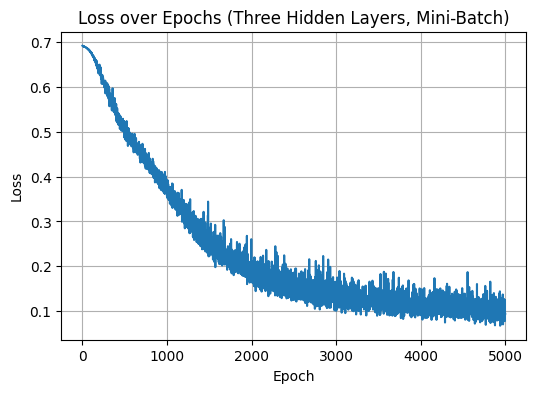

Three-Hidden-Layer Mini-Batch Model Accuracy: 0.9667


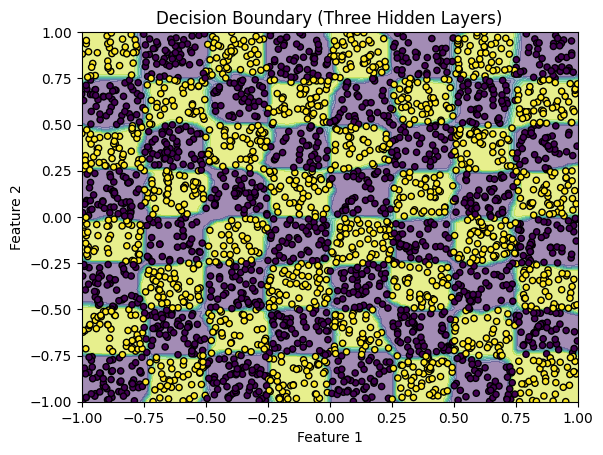

In [ ]:
# Train the model with three hidden layers using mini-batch gradient descent
# Using hidden layer sizes (32, 16, 8) as an example
W1_trained_3layer, b1_trained_3layer, W2_trained_3layer, b2_trained_3layer, W3_trained_3layer, b3_trained_3layer, W4_trained_3layer, b4_trained_3layer, loss_history_3layer = train_mini_batch(
    X, y, hidden_size_1=64, hidden_size_2=32, hidden_size_3=16, lr=0.05, epochs=5000, batch_size=64
)

# Plot the loss history for the three-hidden-layer model
plt.figure(figsize=(6, 4))
plt.plot(loss_history_3layer)
plt.title("Loss over Epochs (Three Hidden Layers, Mini-Batch)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Calculate and print accuracy for the three-hidden-layer mini-batch model
A_3layer, _ = forward(X, W1_trained_3layer, b1_trained_3layer, W2_trained_3layer, b2_trained_3layer, W3_trained_3layer, b3_trained_3layer, W4_trained_3layer, b4_trained_3layer)
accuracy_3layer = calculate_accuracy(y, A_3layer)
print(f"Three-Hidden-Layer Mini-Batch Model Accuracy: {accuracy_3layer:.4f}")

# Plot the decision boundary for the three-hidden-layer model
# The plot_decision_boundary function needs to be updated to handle 4 weight/bias pairs
def plot_decision_boundary_3layer(X, y, model_params):
    xx, yy = np.meshgrid(np.linspace(-1, 1, 100), np.linspace(-1, 1, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]

    W1, b1, W2, b2, W3, b3, W4, b4 = model_params
    A_grid, _ = forward(grid, W1, b1, W2, b2, W3, b3, W4, b4)

    Z = A_grid.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.5)
    plt.scatter(X[:,0], X[:,1], c=y.flatten(), s=20, edgecolor='k')
    plt.title("Decision Boundary (Three Hidden Layers)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary_3layer(X, y, (W1_trained_3layer, b1_trained_3layer, W2_trained_3layer, b2_trained_3layer, W3_trained_3layer, b3_trained_3layer, W4_trained_3layer, b4_trained_3layer))

## Visualize Decision Boundary

In [ ]:
def plot_decision_boundary(X, y, model_params):
    xx, yy = np.meshgrid(np.linspace(-1, 1, 100), np.linspace(-1, 1, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Unpack the trained weights from the 'model_params' tuple based on the new architecture
    # Ensure this matches the return of your 'train' function
    if len(model_params) == 7: # For two hidden layers (if loss_history is included in params)
        W1, b1, W2, b2, W3, b3, _ = model_params # Unpack, ignoring loss_history
        A_grid, _ = forward(grid, W1, b1, W2, b2, W3, b3)
    elif len(model_params) == 6: # For two hidden layers (weights and biases only)
        W1, b1, W2, b2, W3, b3 = model_params
        A_grid, _ = forward(grid, W1, b1, W2, b2, W3, b3)
    elif len(model_params) == 4: # For one hidden layer (original setup)
        W1, b1, W2, b2 = model_params
        A_grid, _ = forward(grid, W1, b1, W2, b2)
    else:
        raise ValueError("model_params tuple has an unexpected number of elements. Check your train function's return values.")

    # Reshape predictions to match the grid dimensions for contour plotting
    Z = A_grid.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.5)
    plt.scatter(X[:,0], X[:,1], c=y.flatten(), s=20, edgecolor='k')
    plt.title("Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

## Run Training

Epoch 0, Loss: 0.6929
Epoch 100, Loss: 0.6842
Epoch 200, Loss: 0.6798
Epoch 300, Loss: 0.6767
Epoch 400, Loss: 0.6744
Epoch 500, Loss: 0.6722
Epoch 600, Loss: 0.6699
Epoch 700, Loss: 0.6675
Epoch 800, Loss: 0.6651
Epoch 900, Loss: 0.6624
Epoch 1000, Loss: 0.6594
Epoch 1100, Loss: 0.6561
Epoch 1200, Loss: 0.6525
Epoch 1300, Loss: 0.6485
Epoch 1400, Loss: 0.6438
Epoch 1500, Loss: 0.6383
Epoch 1600, Loss: 0.6323
Epoch 1700, Loss: 0.6257
Epoch 1800, Loss: 0.6185
Epoch 1900, Loss: 0.6107
Epoch 2000, Loss: 0.6021
Epoch 2100, Loss: 0.5930
Epoch 2200, Loss: 0.5834
Epoch 2300, Loss: 0.5733
Epoch 2400, Loss: 0.5628
Epoch 2500, Loss: 0.5519
Epoch 2600, Loss: 0.5405
Epoch 2700, Loss: 0.5289
Epoch 2800, Loss: 0.5173
Epoch 2900, Loss: 0.5058
Epoch 3000, Loss: 0.4944
Epoch 3100, Loss: 0.4832
Epoch 3200, Loss: 0.4724
Epoch 3300, Loss: 0.4621
Epoch 3400, Loss: 0.4523
Epoch 3500, Loss: 0.4429
Epoch 3600, Loss: 0.4342
Epoch 3700, Loss: 0.4263
Epoch 3800, Loss: 0.4188
Epoch 3900, Loss: 0.4117
Epoch 4000, 

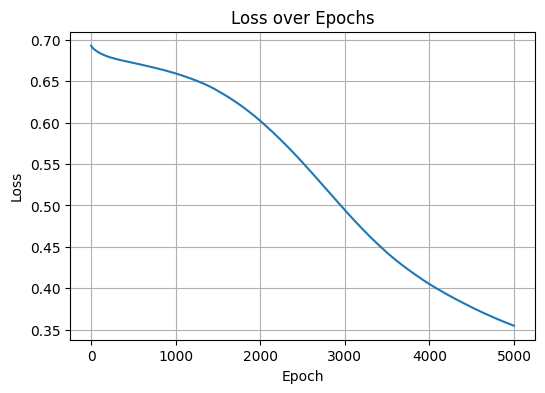

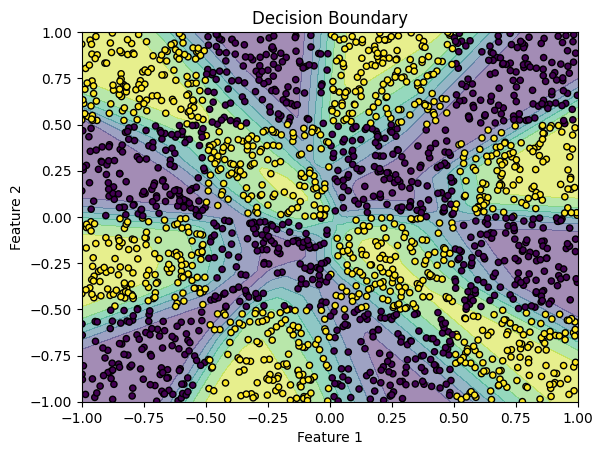

In [ ]:
# Train your model with two hidden layers and get loss history, and trained weights
W1_trained, b1_trained, W2_trained, b2_trained, W3_trained, b3_trained, loss_history = train(X, y, hidden_size_1=32, hidden_size_2=16, lr=0.05)

# Plot the loss history
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Plot the decision boundary
# Note: The plot_decision_boundary function will need to be updated to accept the new number of weight/bias parameters
# For now, let's pass a tuple compatible with the current plot_decision_boundary function (first hidden layer weights)
plot_decision_boundary(X, y, (W1_trained, b1_trained, W2_trained, b2_trained, W3_trained, b3_trained))

In [ ]:
# Calculate and print accuracy for the full-batch model
A3_full_batch, _ = forward(X, W1_trained, b1_trained, W2_trained, b2_trained, W3_trained, b3_trained)
accuracy_full_batch = calculate_accuracy(y, A3_full_batch)
print(f"Full-Batch Model Accuracy: {accuracy_full_batch:.4f}")

Full-Batch Model Accuracy: 0.8565


Epoch 0, Loss: 0.6920
Epoch 100, Loss: 0.5061
Epoch 200, Loss: 0.3932
Epoch 300, Loss: 0.3170
Epoch 400, Loss: 0.2191
Epoch 500, Loss: 0.1808
Epoch 600, Loss: 0.1369
Epoch 700, Loss: 0.1666
Epoch 800, Loss: 0.1095
Epoch 900, Loss: 0.0874
Epoch 1000, Loss: 0.0977
Epoch 1100, Loss: 0.0861
Epoch 1200, Loss: 0.0767
Epoch 1300, Loss: 0.0718
Epoch 1400, Loss: 0.0712
Epoch 1500, Loss: 0.0620
Epoch 1600, Loss: 0.0739
Epoch 1700, Loss: 0.0833
Epoch 1800, Loss: 0.0850
Epoch 1900, Loss: 0.0562
Epoch 2000, Loss: 0.0530
Epoch 2100, Loss: 0.0613
Epoch 2200, Loss: 0.1123
Epoch 2300, Loss: 0.0474
Epoch 2400, Loss: 0.1574
Epoch 2500, Loss: 0.0537
Epoch 2600, Loss: 0.0466
Epoch 2700, Loss: 0.0674
Epoch 2800, Loss: 0.0475
Epoch 2900, Loss: 0.0444
Epoch 3000, Loss: 0.0492
Epoch 3100, Loss: 0.0366
Epoch 3200, Loss: 0.0370
Epoch 3300, Loss: 0.0286
Epoch 3400, Loss: 0.0555
Epoch 3500, Loss: 0.0873
Epoch 3600, Loss: 0.0438
Epoch 3700, Loss: 0.0394
Epoch 3800, Loss: 0.0422
Epoch 3900, Loss: 0.0476
Epoch 4000, 

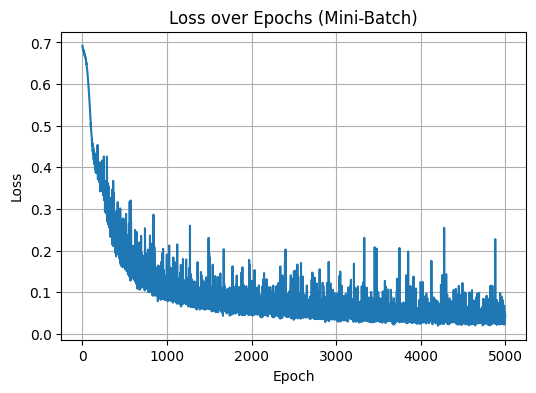

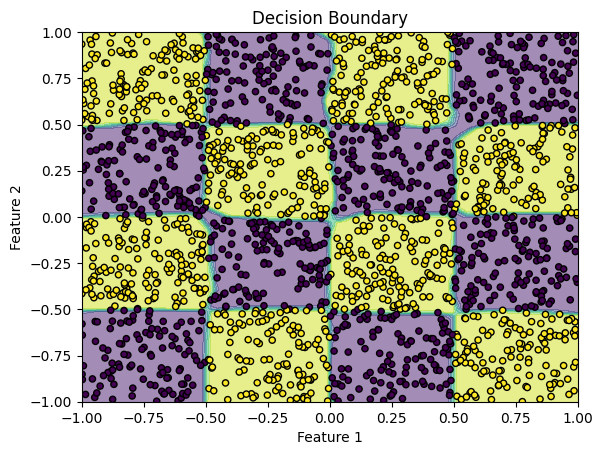

In [ ]:
# Train your model with mini-batch gradient descent
W1_trained_mb, b1_trained_mb, W2_trained_mb, b2_trained_mb, W3_trained_mb, b3_trained_mb, loss_history_mb = train_mini_batch(X, y, hidden_size_1=32, hidden_size_2=16, lr=0.05, epochs=5000, batch_size=64)

# Plot the loss history
plt.figure(figsize=(6, 4))
plt.plot(loss_history_mb)
plt.title("Loss over Epochs (Mini-Batch)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Plot the decision boundary
plot_decision_boundary(X, y, (W1_trained_mb, b1_trained_mb, W2_trained_mb, b2_trained_mb, W3_trained_mb, b3_trained_mb))

In [ ]:
# Calculate and print accuracy for the mini-batch model
A3_mini_batch, _ = forward(X, W1_trained_mb, b1_trained_mb, W2_trained_mb, b2_trained_mb, W3_trained_mb, b3_trained_mb)
accuracy_mini_batch = calculate_accuracy(y, A3_mini_batch)
print(f"Mini-Batch Model Accuracy: {accuracy_mini_batch:.4f}")

Mini-Batch Model Accuracy: 0.9895



---

## ⭐ Extra Credit ( For Concept And Code, 20% add on )

### Circle Classification Problem

Instead of a checkerboard, classify points based on whether they lie inside a circle:

- Input: (x, y)
- Output: 1 if inside circle, else 0

Decision boundary:
x² + y² < r²

### Questions:
1. Why is this non-linear?
2. Would a single-layer perceptron work?
3. How would the decision boundary differ from the checkerboard?

---

